# 🎓 Impact of Lifestyle on Academic Performance
### Exploring how daily habits — study, sleep, stress, and activity — shape student GPA

---
**Dataset:** Student Lifestyle Dataset (Kaggle) — 2,000 students, 7 lifestyle variables + GPA  
**Goal:** Identify which lifestyle factors most strongly predict academic performance

## 1. Setup — Import Libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
import warnings
warnings.filterwarnings('ignore')

# Visual style
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11

## 2. Load the Dataset

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving student_lifestyle_dataset.csv to student_lifestyle_dataset.csv


In [ ]:
df = pd.read_csv("student_lifestyle_dataset.csv")
print(f"✅ Dataset loaded: {df.shape[0]} students, {df.shape[1]} columns")
df.head()

✅ Dataset loaded: 2000 students, 8 columns


,Student_ID,Study_Hours_Per_Day,Extracurricular_Hours_Per_Day,Sleep_Hours_Per_Day,Social_Hours_Per_Day,Physical_Activity_Hours_Per_Day,GPA,Stress_Level
0,1,6.9,3.8,8.7,2.8,1.8,2.99,Moderate
1,2,5.3,3.5,8.0,4.2,3.0,2.75,Low
2,3,5.1,3.9,9.2,1.2,4.6,2.67,Low
3,4,6.5,2.1,7.2,1.7,6.5,2.88,Moderate
4,5,8.1,0.6,6.5,2.2,6.6,3.51,High


## 3. Dataset Overview

In [ ]:
# Column names, data types, and non-null counts
print("Shape:", df.shape)
print()
df.info()

Shape: (2000, 8)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 8 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Student_ID                       2000 non-null   int64  
 1   Study_Hours_Per_Day              2000 non-null   float64
 2   Extracurricular_Hours_Per_Day    2000 non-null   float64
 3   Sleep_Hours_Per_Day              2000 non-null   float64
 4   Social_Hours_Per_Day             2000 non-null   float64
 5   Physical_Activity_Hours_Per_Day  2000 non-null   float64
 6   GPA                              2000 non-null   float64
 7   Stress_Level                     2000 non-null   object 
dtypes: float64(6), int64(1), object(1)
memory usage: 125.1+ KB


In [ ]:
# Summary statistics for all numeric columns
df.describe().round(2)

,Student_ID,Study_Hours_Per_Day,Extracurricular_Hours_Per_Day,Sleep_Hours_Per_Day,Social_Hours_Per_Day,Physical_Activity_Hours_Per_Day,GPA
count,2000.00,2000.00,2000.00,2000.00,2000.00,2000.00,2000.00
mean,1000.50,7.48,1.99,7.50,2.70,4.33,3.12
std,577.49,1.42,1.16,1.46,1.69,2.51,0.30
min,1.00,5.00,0.00,5.00,0.00,0.00,2.24
25%,500.75,6.30,1.00,6.20,1.20,2.40,2.90
50%,1000.50,7.40,2.00,7.50,2.60,4.10,3.11
75%,1500.25,8.70,3.00,8.80,4.10,6.10,3.33
max,2000.00,10.00,4.00,10.00,6.00,13.00,4.00


## 4. Data Cleaning

Before analysis, we verify the dataset has no issues that could distort our results.

In [ ]:
# ── Check 1: Duplicate rows 
dupes = df.duplicated().sum()
print(f"Duplicate rows: {dupes}")

# ── Check 2: Missing values 
missing = df.isnull().sum()
print("\nMissing values per column:")
print(missing)
print(f"\nTotal missing: {missing.sum()}")


# Z-score > 3 means the value is more than 3 standard deviations from the mean
# (only ~0.3% of data in a normal distribution) — flagged as suspicious
print("\nOutliers detected (|Z-score| > 3):")
numeric_cols = df.select_dtypes(include=np.number).drop(columns=['Student_ID']).columns
for col in numeric_cols:
    z_scores = np.abs(stats.zscore(df[col]))
    n_outliers = (z_scores > 3).sum()
    print(f"  {col}: {n_outliers} outliers")

print("\n✅ Dataset is clean — all 2,000 rows retained for analysis.")

Duplicate rows: 0

Missing values per column:
Student_ID                         0
Study_Hours_Per_Day                0
Extracurricular_Hours_Per_Day      0
Sleep_Hours_Per_Day                0
Social_Hours_Per_Day               0
Physical_Activity_Hours_Per_Day    0
GPA                                0
Stress_Level                       0
dtype: int64

Total missing: 0

Outliers detected (|Z-score| > 3):
  Study_Hours_Per_Day: 0 outliers
  Extracurricular_Hours_Per_Day: 0 outliers
  Sleep_Hours_Per_Day: 0 outliers
  Social_Hours_Per_Day: 0 outliers
  Physical_Activity_Hours_Per_Day: 4 outliers
  GPA: 0 outliers

✅ Dataset is clean — all 2,000 rows retained for analysis.


In [ ]:
# Stress_Level is categorical 
print("Stress Level categories:", df['Stress_Level'].unique())
print("\nValue counts:")
print(df['Stress_Level'].value_counts())

Stress Level categories: ['Moderate' 'Low' 'High']

Value counts:
Stress_Level
High        1029
Moderate     674
Low          297
Name: count, dtype: int64


## 5. Exploratory Data Analysis (EDA)

We explore the distribution of each variable before running any statistical tests.

### 5a. GPA Distribution — Our Target Variable

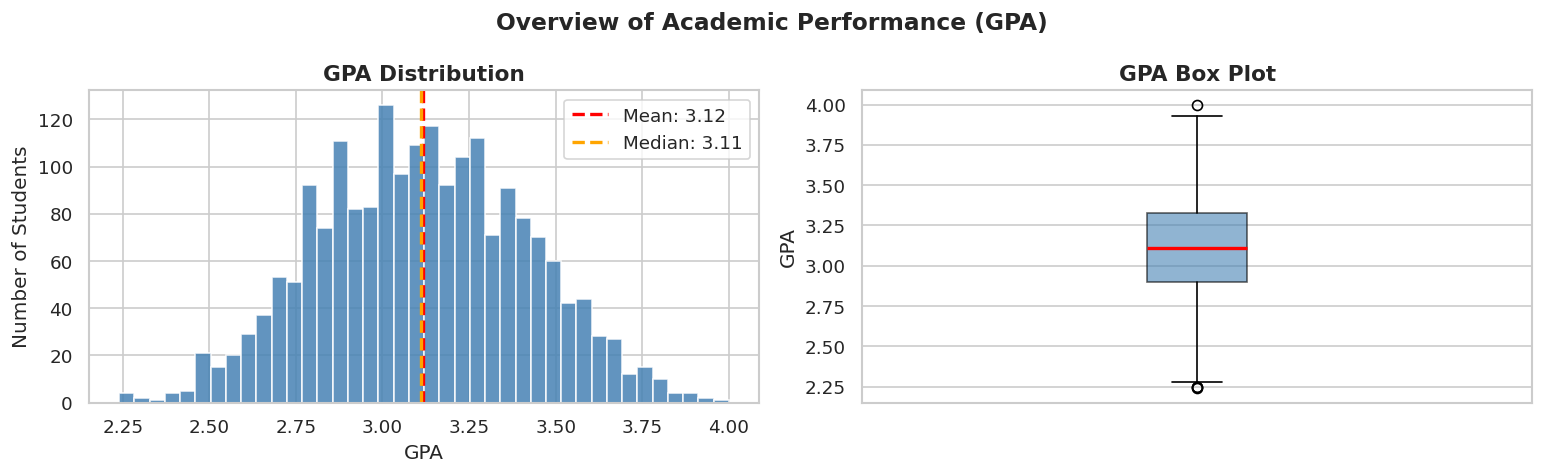

Min GPA: 2.24  |  Max GPA: 4.00  |  Std: 0.30


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Histogram
axes[0].hist(df['GPA'], bins=40, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].axvline(df['GPA'].mean(), color='red', linestyle='--', linewidth=2,
                label=f"Mean: {df['GPA'].mean():.2f}")
axes[0].axvline(df['GPA'].median(), color='orange', linestyle='--', linewidth=2,
                label=f"Median: {df['GPA'].median():.2f}")
axes[0].set_title('GPA Distribution', fontsize=13, fontweight='bold')
axes[0].set_xlabel('GPA')
axes[0].set_ylabel('Number of Students')
axes[0].legend()

# Box plot
axes[1].boxplot(df['GPA'], patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.6),
                medianprops=dict(color='red', linewidth=2))
axes[1].set_title('GPA Box Plot', fontsize=13, fontweight='bold')
axes[1].set_ylabel('GPA')
axes[1].set_xticks([])

plt.suptitle('Overview of Academic Performance (GPA)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Min GPA: {df['GPA'].min():.2f}  |  Max GPA: {df['GPA'].max():.2f}  |  Std: {df['GPA'].std():.2f}")

### 5b. Distribution of All Lifestyle Variables

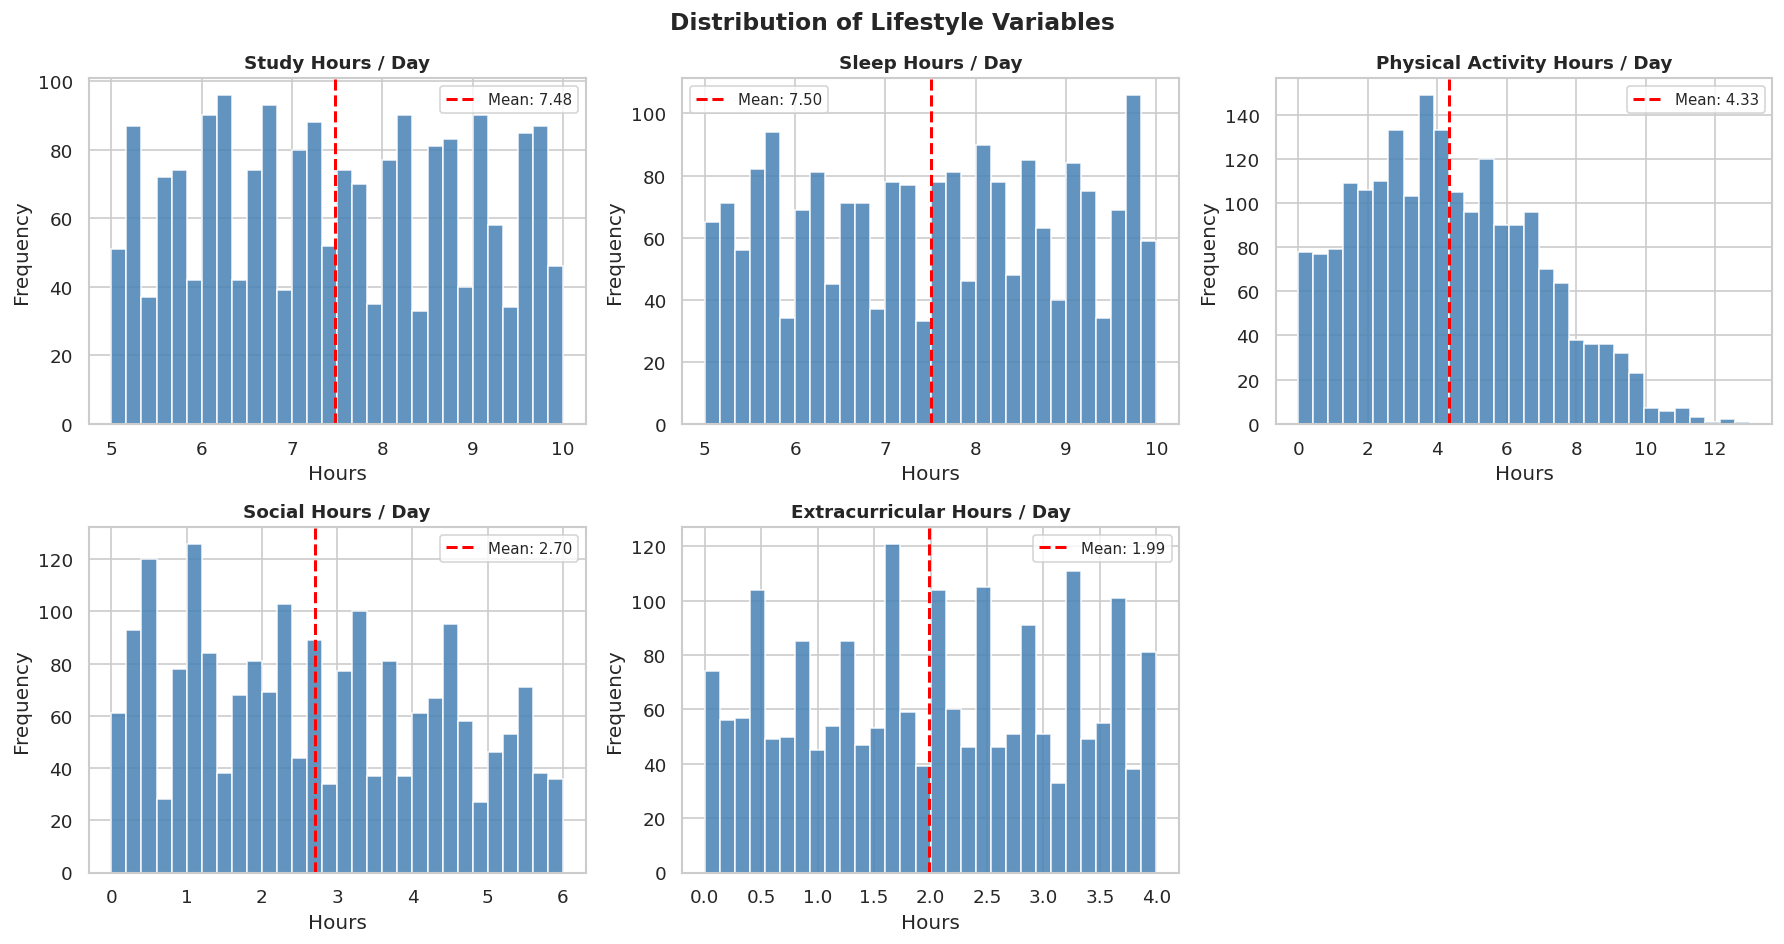

In [ ]:
lifestyle_vars = {
    'Study_Hours_Per_Day': 'Study Hours / Day',
    'Sleep_Hours_Per_Day': 'Sleep Hours / Day',
    'Physical_Activity_Hours_Per_Day': 'Physical Activity Hours / Day',
    'Social_Hours_Per_Day': 'Social Hours / Day',
    'Extracurricular_Hours_Per_Day': 'Extracurricular Hours / Day'
}

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, (col, label) in enumerate(lifestyle_vars.items()):
    axes[i].hist(df[col], bins=30, color='steelblue', edgecolor='white', alpha=0.85)
    axes[i].axvline(df[col].mean(), color='red', linestyle='--', linewidth=1.8,
                    label=f'Mean: {df[col].mean():.2f}')
    axes[i].set_title(label, fontsize=11, fontweight='bold')
    axes[i].set_xlabel('Hours')
    axes[i].set_ylabel('Frequency')
    axes[i].legend(fontsize=9)

# Hide the 6th (unused) subplot
axes[-1].set_visible(False)

plt.suptitle('Distribution of Lifestyle Variables', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 5c. Stress Level — Category Breakdown

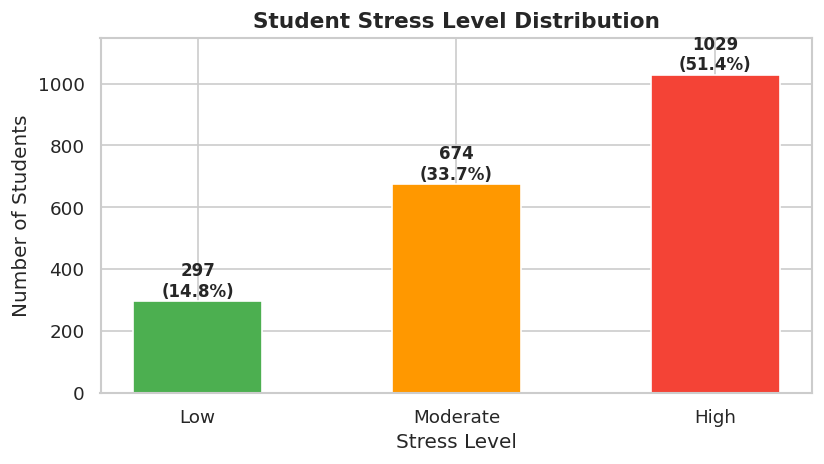

In [ ]:
stress_counts = df['Stress_Level'].value_counts().reindex(['Low', 'Moderate', 'High'])
stress_colors = ['#4CAF50', '#FF9800', '#F44336']

plt.figure(figsize=(7, 4))
bars = plt.bar(stress_counts.index, stress_counts.values, color=stress_colors, edgecolor='white', width=0.5)
for bar, val in zip(bars, stress_counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 15,
             f'{val}\n({val/len(df)*100:.1f}%)', ha='center', fontsize=10, fontweight='bold')
plt.title('Student Stress Level Distribution', fontsize=13, fontweight='bold')
plt.xlabel('Stress Level')
plt.ylabel('Number of Students')
plt.ylim(0, stress_counts.max() + 120)
plt.tight_layout()
plt.show()

## 6. Correlation Analysis

We use Pearson correlation to measure how strongly each lifestyle variable is linearly related to GPA.  
*(r closer to +1 = strong positive, r closer to -1 = strong negative, r ≈ 0 = no linear relationship)*

In [ ]:
# Pearson r and p-value for each variable vs GPA
print(f"{'Variable':<40} {'Pearson r':>10}  {'p-value':>12}  {'Significant?':>12}")
print("-" * 78)

lifestyle_cols = ['Study_Hours_Per_Day', 'Sleep_Hours_Per_Day',
                  'Physical_Activity_Hours_Per_Day', 'Social_Hours_Per_Day',
                  'Extracurricular_Hours_Per_Day']

results = []
for col in lifestyle_cols:
    r, p = stats.pearsonr(df[col], df['GPA'])
    sig = "✅ Yes" if p < 0.05 else "❌ No"
    results.append({'Variable': col, 'r': r, 'p': p})
    print(f"{col:<40} {r:>10.4f}  {p:>12.2e}  {sig:>12}")

Variable                                  Pearson r       p-value  Significant?
------------------------------------------------------------------------------
Study_Hours_Per_Day                          0.7345      0.00e+00         ✅ Yes
Sleep_Hours_Per_Day                         -0.0043      8.48e-01          ❌ No
Physical_Activity_Hours_Per_Day             -0.3412      1.08e-55         ✅ Yes
Social_Hours_Per_Day                        -0.0857      1.25e-04         ✅ Yes
Extracurricular_Hours_Per_Day               -0.0322      1.50e-01          ❌ No


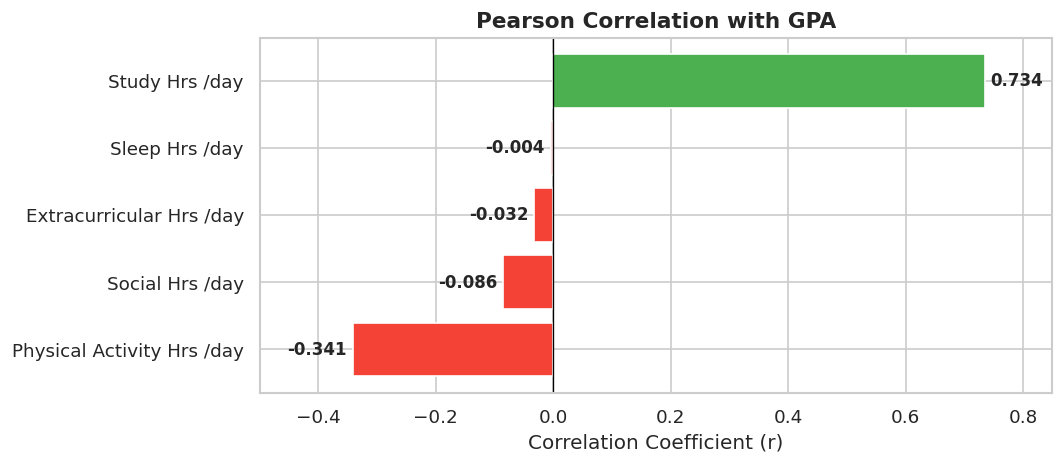

In [ ]:
# Horizontal bar chart — correlations with GPA
corr_df = pd.DataFrame(results).sort_values('r', ascending=True)
colors = ['#4CAF50' if r > 0 else '#F44336' for r in corr_df['r']]
labels = [c.replace('_', ' ').replace('Per Day', '/day').replace('Hours', 'Hrs') for c in corr_df['Variable']]

plt.figure(figsize=(9, 4))
bars = plt.barh(labels, corr_df['r'], color=colors, edgecolor='white')
plt.axvline(0, color='black', linewidth=0.8)
for bar, val in zip(bars, corr_df['r']):
    offset = 0.01 if val >= 0 else -0.01
    ha = 'left' if val >= 0 else 'right'
    plt.text(val + offset, bar.get_y() + bar.get_height()/2,
             f'{val:.3f}', va='center', ha=ha, fontsize=10, fontweight='bold')
plt.title('Pearson Correlation with GPA', fontsize=13, fontweight='bold')
plt.xlabel('Correlation Coefficient (r)')
plt.xlim(-0.5, 0.85)
plt.tight_layout()
plt.show()

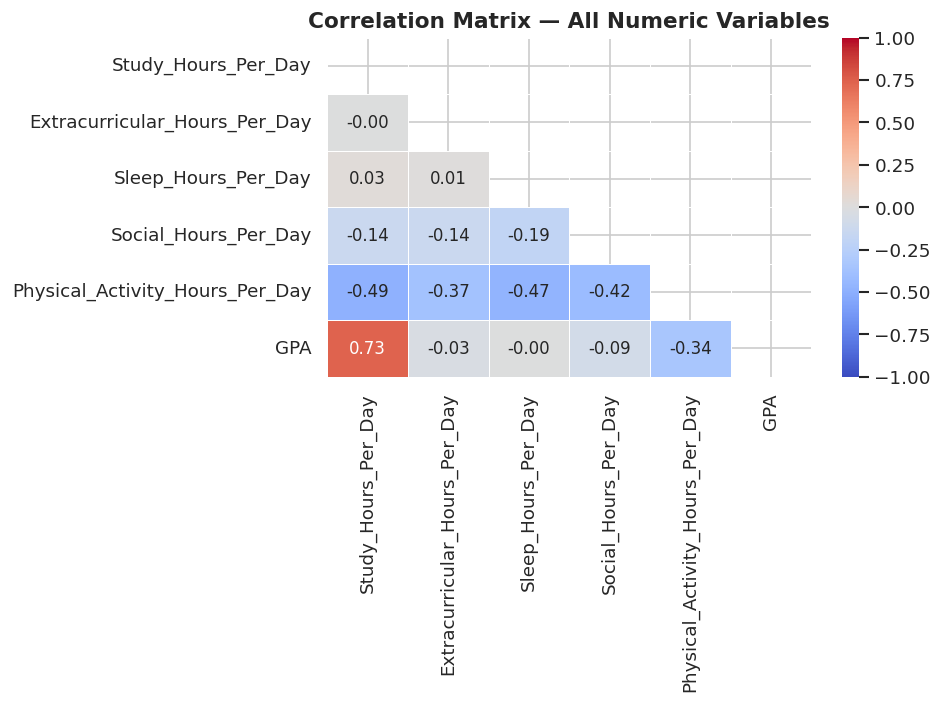

In [ ]:
# Full correlation heatmap (all numeric variables)
plt.figure(figsize=(8, 6))
numeric_df = df.select_dtypes(include='number').drop(columns=['Student_ID'])
corr_matrix = numeric_df.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            mask=mask, linewidths=0.5, vmin=-1, vmax=1, annot_kws={'size': 10})
plt.title('Correlation Matrix — All Numeric Variables', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 7. Key Relationships with GPA — Scatter Plots

Each scatter plot shows the raw data points and a fitted trend line.  
The slope of the trend line tells us the direction and magnitude of the relationship.

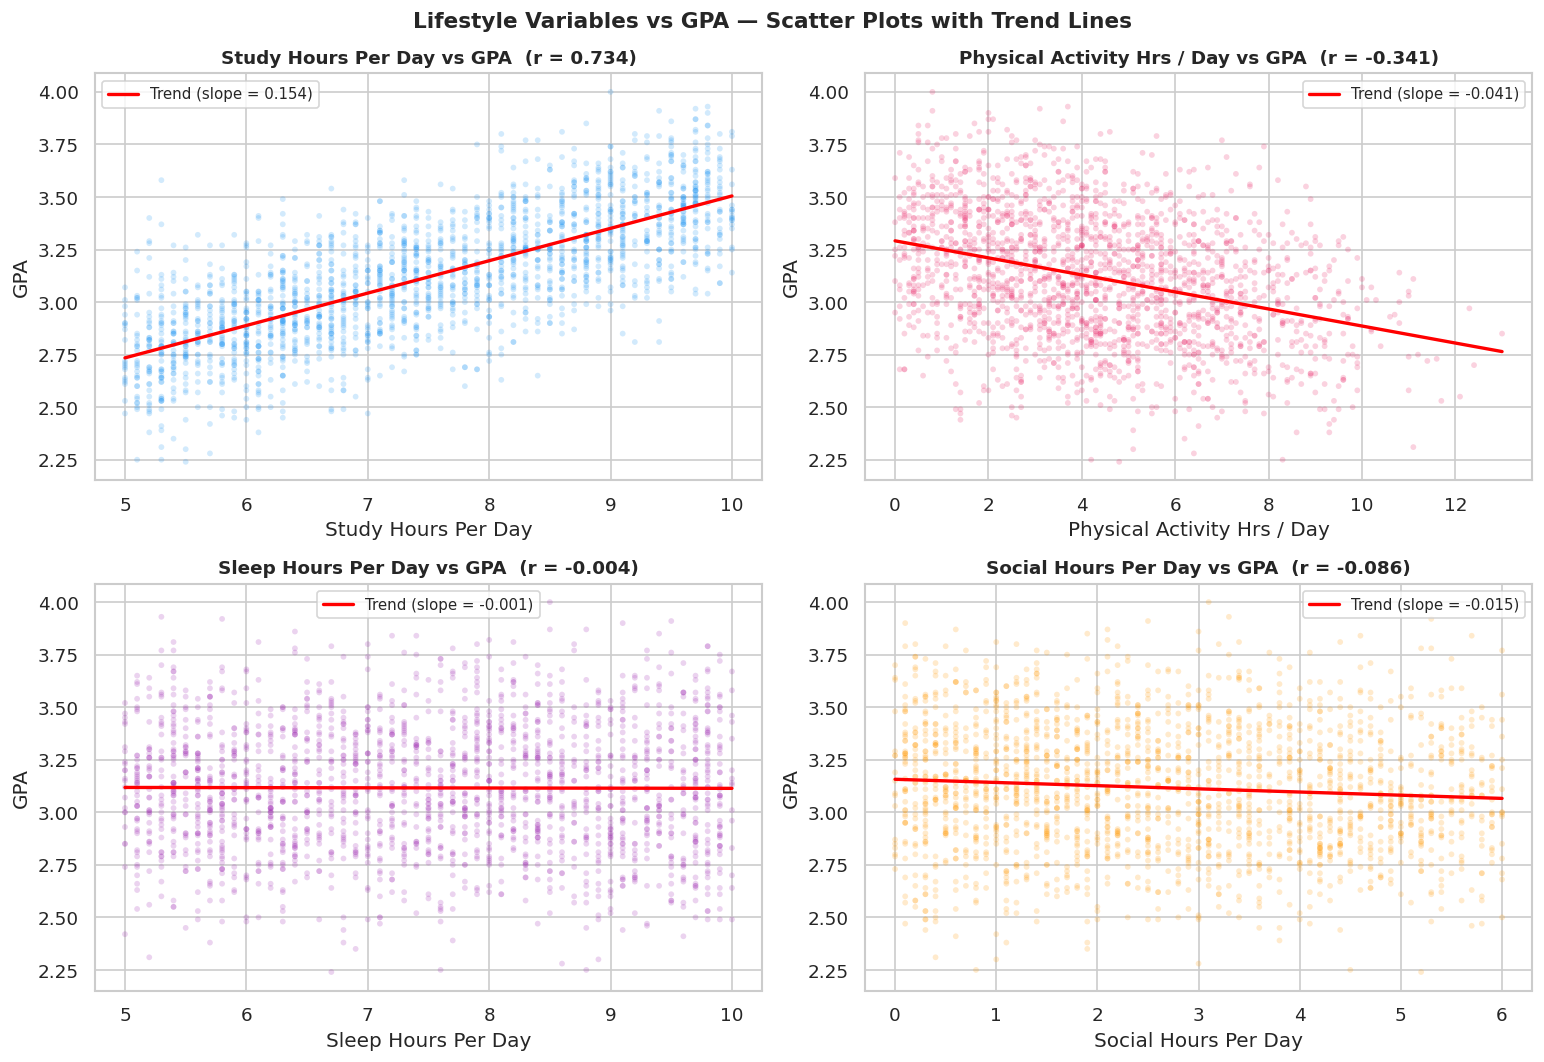

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
axes = axes.flatten()

scatter_pairs = [
    ('Study_Hours_Per_Day',              'Study Hours Per Day',         '#2196F3'),
    ('Physical_Activity_Hours_Per_Day',  'Physical Activity Hrs / Day', '#E91E63'),
    ('Sleep_Hours_Per_Day',              'Sleep Hours Per Day',         '#9C27B0'),
    ('Social_Hours_Per_Day',             'Social Hours Per Day',        '#FF9800'),
]

for ax, (col, xlabel, color) in zip(axes, scatter_pairs):
    ax.scatter(df[col], df['GPA'], alpha=0.2, color=color, s=12, edgecolors='none')
    m, b = np.polyfit(df[col], df['GPA'], 1)
    x_range = np.linspace(df[col].min(), df[col].max(), 100)
    ax.plot(x_range, m * x_range + b, color='red', linewidth=2,
            label=f'Trend (slope = {m:.3f})')
    r, _ = stats.pearsonr(df[col], df['GPA'])
    ax.set_title(f'{xlabel} vs GPA  (r = {r:.3f})', fontsize=11, fontweight='bold')
    ax.set_xlabel(xlabel)
    ax.set_ylabel('GPA')
    ax.legend(fontsize=9)

plt.suptitle('Lifestyle Variables vs GPA — Scatter Plots with Trend Lines',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 8. Group Comparisons — Box Plots

Box plots let us compare GPA distributions across meaningful groups, not just individual data points.

### 8a. GPA by Stress Level

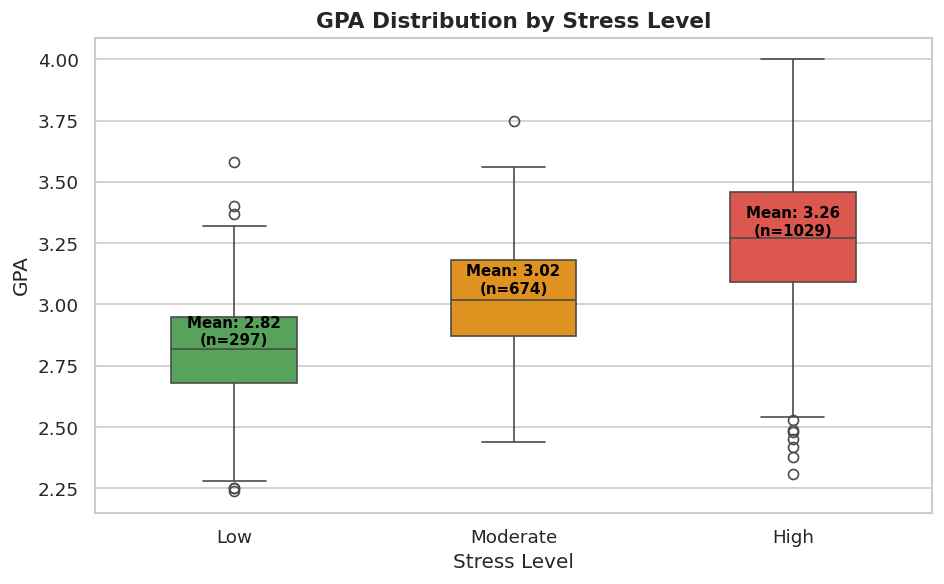

Mean GPA by Stress Level:
               mean  median    std  count
Stress_Level                             
High          3.262    3.27  0.275   1029
Low           2.817    2.82  0.215    297
Moderate      3.025    3.02  0.221    674


In [ ]:
stress_order = ['Low', 'Moderate', 'High']
stress_palette = {'Low': '#4CAF50', 'Moderate': '#FF9800', 'High': '#F44336'}

plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='Stress_Level', y='GPA', order=stress_order,
            palette=stress_palette, width=0.45)

# Annotate with group means
for i, level in enumerate(stress_order):
    mean_val = df[df['Stress_Level'] == level]['GPA'].mean()
    n = df[df['Stress_Level'] == level].shape[0]
    plt.text(i, mean_val + 0.02, f'Mean: {mean_val:.2f}\n(n={n})',
             ha='center', fontsize=9, fontweight='bold', color='black')

plt.title('GPA Distribution by Stress Level', fontsize=13, fontweight='bold')
plt.xlabel('Stress Level')
plt.ylabel('GPA')
plt.tight_layout()
plt.show()

# Print a summary table
print("Mean GPA by Stress Level:")
print(df.groupby('Stress_Level')['GPA'].agg(['mean','median','std','count']).round(3))

### 8b. GPA by Sleep Duration Category

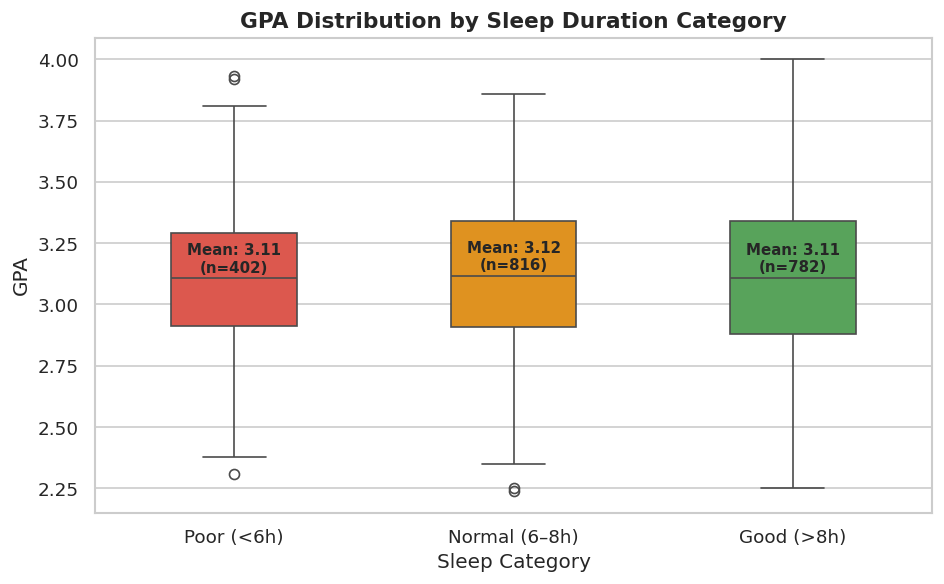

Mean GPA by Sleep Category:
                 mean  median    std  count
sleep_category                             
Good (>8h)      3.113   3.110  0.312    782
Normal (6–8h)   3.120   3.115  0.292    816
Poor (<6h)      3.112   3.110  0.284    402


In [ ]:
# Create sleep categories
def categorize_sleep(h):
    if h < 6:   return 'Poor (<6h)'
    elif h <= 8: return 'Normal (6–8h)'
    else:        return 'Good (>8h)'

df['sleep_category'] = df['Sleep_Hours_Per_Day'].apply(categorize_sleep)
sleep_order   = ['Poor (<6h)', 'Normal (6–8h)', 'Good (>8h)']
sleep_palette = {'Poor (<6h)': '#F44336', 'Normal (6–8h)': '#FF9800', 'Good (>8h)': '#4CAF50'}

plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='sleep_category', y='GPA',
            order=sleep_order, palette=sleep_palette, width=0.45)

for i, cat in enumerate(sleep_order):
    mean_val = df[df['sleep_category'] == cat]['GPA'].mean()
    n = df[df['sleep_category'] == cat].shape[0]
    plt.text(i, mean_val + 0.02, f'Mean: {mean_val:.2f}\n(n={n})',
             ha='center', fontsize=9, fontweight='bold')

plt.title('GPA Distribution by Sleep Duration Category', fontsize=13, fontweight='bold')
plt.xlabel('Sleep Category')
plt.ylabel('GPA')
plt.tight_layout()
plt.show()

print("Mean GPA by Sleep Category:")
print(df.groupby('sleep_category')['GPA'].agg(['mean','median','std','count']).round(3))

### 8c. GPA by Study Hours Quartile

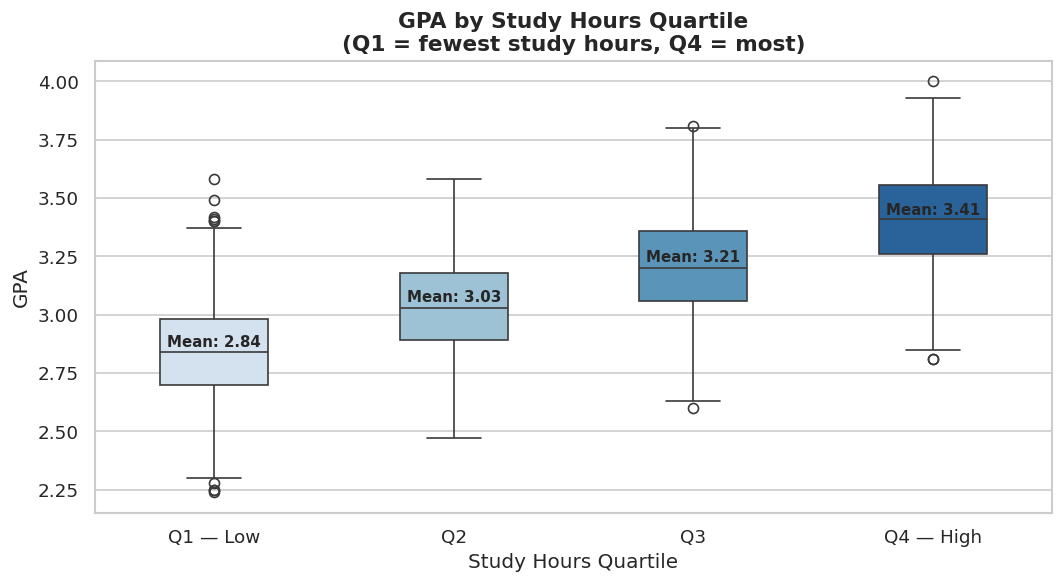

Mean GPA by Study Quartile:
                 mean   min   max  count
study_quartile                          
Q1 — Low        2.843  2.24  3.58    549
Q2              3.034  2.47  3.58    468
Q3              3.206  2.60  3.81    496
Q4 — High       3.410  2.81  4.00    487


In [ ]:
df['study_quartile'] = pd.qcut(df['Study_Hours_Per_Day'], q=4,
                                labels=['Q1 — Low', 'Q2', 'Q3', 'Q4 — High'])

plt.figure(figsize=(9, 5))
sns.boxplot(data=df, x='study_quartile', y='GPA',
            palette='Blues', width=0.45, order=['Q1 — Low', 'Q2', 'Q3', 'Q4 — High'])

for i, q in enumerate(['Q1 — Low', 'Q2', 'Q3', 'Q4 — High']):
    mean_val = df[df['study_quartile'] == q]['GPA'].mean()
    plt.text(i, mean_val + 0.02, f'Mean: {mean_val:.2f}',
             ha='center', fontsize=9, fontweight='bold')
plt.title('GPA by Study Hours Quartile\n(Q1 = fewest study hours, Q4 = most)',
          fontsize=13, fontweight='bold')
plt.xlabel('Study Hours Quartile')
plt.ylabel('GPA')
plt.tight_layout()
plt.show()

print("Mean GPA by Study Quartile:")
print(df.groupby('study_quartile', observed=True)['GPA'].agg(['mean','min','max','count']).round(3))

## 9. Multiple Linear Regression — Predicting GPA

We build a regression model to quantify each factor's **independent contribution** to GPA,  
controlling for all other variables simultaneously.

> **Model:** GPA = β₀ + β₁·StudyHours + β₂·SleepHours + β₃·PhysicalActivity + β₄·SocialHours + β₅·Extracurricular + β₆·StressLevel

In [ ]:
# Encode Stress_Level as numeric (ordinal: Low=1, Moderate=2, High=3)
stress_map = {'Low': 1, 'Moderate': 2, 'High': 3}
df['Stress_Encoded'] = df['Stress_Level'].map(stress_map)

features = ['Study_Hours_Per_Day', 'Sleep_Hours_Per_Day',
            'Physical_Activity_Hours_Per_Day', 'Social_Hours_Per_Day',
            'Extracurricular_Hours_Per_Day', 'Stress_Encoded']

X = df[features]
y = df['GPA']

# 80/20 train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

r2   = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print("📊 Model Performance")
print(f"   R²   = {r2:.4f}  → the model explains {r2*100:.1f}% of variance in GPA")
print(f"   RMSE = {rmse:.4f}  → average prediction error of ±{rmse:.2f} GPA points")

📊 Model Performance
   R²   = 0.5494  → the model explains 54.9% of variance in GPA
   RMSE = 0.2051  → average prediction error of ±0.21 GPA points


In [ ]:
# Coefficients table
feature_labels = ['Study Hours/Day', 'Sleep Hours/Day', 'Physical Activity Hrs/Day',
                   'Social Hours/Day', 'Extracurricular Hrs/Day', 'Stress Level (encoded)']

coef_df = pd.DataFrame({
    'Feature':     feature_labels,
    'Coefficient': model.coef_
}).sort_values('Coefficient', ascending=False).reset_index(drop=True)

print(f"Intercept (β₀): {model.intercept_:.4f}")
print("\nRegression Coefficients:")
print(coef_df.to_string(index=False))
print("\n→ A positive coefficient means more of that variable predicts a HIGHER GPA.")
print("→ A negative coefficient means more predicts a LOWER GPA.")

Intercept (β₀): 2.6811

Regression Coefficients:
                  Feature  Coefficient
          Study Hours/Day     0.124690
   Stress Level (encoded)     0.002718
         Social Hours/Day    -0.027471
Physical Activity Hrs/Day    -0.027988
          Sleep Hours/Day    -0.031068
  Extracurricular Hrs/Day    -0.038163

→ A positive coefficient means more of that variable predicts a HIGHER GPA.
→ A negative coefficient means more predicts a LOWER GPA.


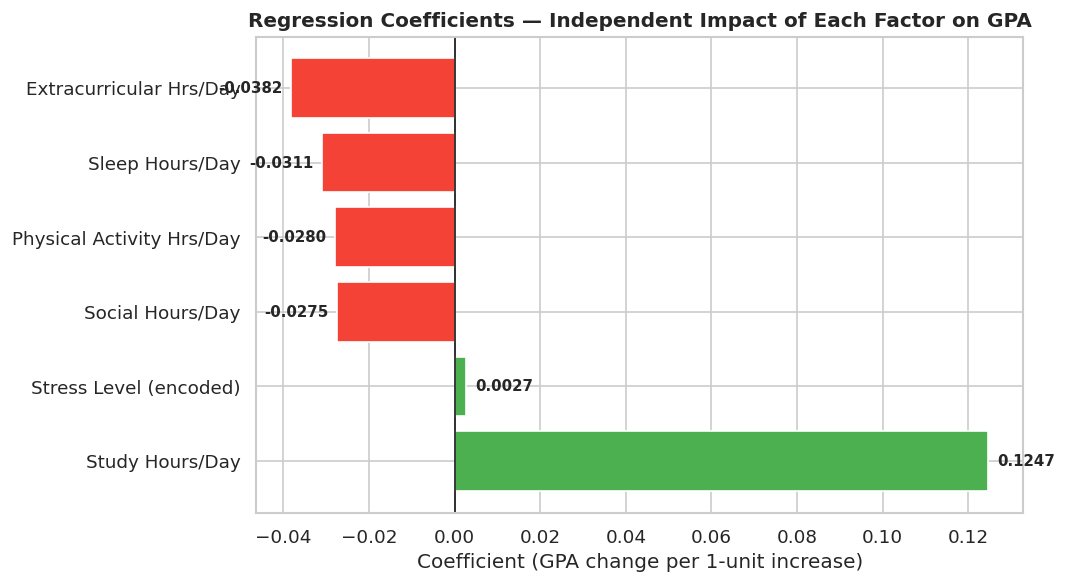

In [ ]:
# Coefficient bar chart
colors = ['#4CAF50' if v > 0 else '#F44336' for v in coef_df['Coefficient']]

plt.figure(figsize=(9, 5))
bars = plt.barh(coef_df['Feature'], coef_df['Coefficient'], color=colors, edgecolor='white')
plt.axvline(0, color='black', linewidth=0.9)
for bar, val in zip(bars, coef_df['Coefficient']):
    offset = 0.002 if val >= 0 else -0.002
    ha = 'left' if val >= 0 else 'right'
    plt.text(val + offset, bar.get_y() + bar.get_height()/2,
             f'{val:.4f}', va='center', ha=ha, fontsize=9, fontweight='bold')
plt.title('Regression Coefficients — Independent Impact of Each Factor on GPA',
          fontsize=12, fontweight='bold')
plt.xlabel('Coefficient (GPA change per 1-unit increase)')
plt.tight_layout()
plt.show()

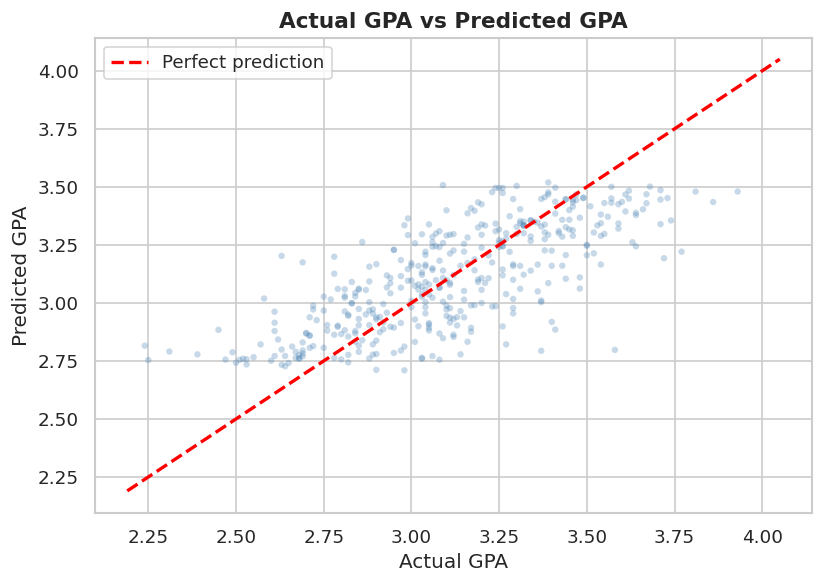

In [ ]:
# Actual vs Predicted GPA
plt.figure(figsize=(7, 5))
plt.scatter(y_test, y_pred, alpha=0.3, color='steelblue', s=15, edgecolors='none')
lims = [y.min() - 0.05, y.max() + 0.05]
plt.plot(lims, lims, color='red', linewidth=2, linestyle='--', label='Perfect prediction')
plt.title('Actual GPA vs Predicted GPA', fontsize=13, fontweight='bold')
plt.xlabel('Actual GPA')
plt.ylabel('Predicted GPA')
plt.legend()
plt.tight_layout()
plt.show()

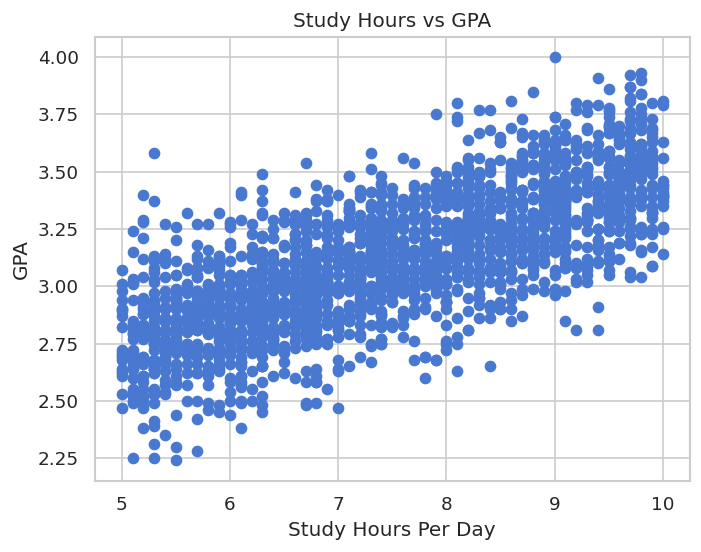

In [ ]:
#scatter plot
plt.figure()
plt.scatter(df['Study_Hours_Per_Day'], df['GPA'])
plt.xlabel('Study Hours Per Day')
plt.ylabel('GPA')
plt.title('Study Hours vs GPA')
plt.show()

## 10. Conclusions & Research Question Answers

---

### Research Question 1: Is there a relationship between lifestyle habits and academic performance?
**Yes.** The regression model (R² = 0.55) shows that lifestyle variables together explain 55% of the variance in GPA — a meaningful relationship.

---

### Research Question 2: Does regular physical activity improve GPA outcomes?
**Surprisingly, no** — in this dataset, physical activity shows a **negative** correlation with GPA (r = −0.34). Students who exercise more actually tend to have slightly lower GPAs. This likely reflects a **time trade-off**: hours spent on physical activity are hours not spent studying.

---

### Research Question 3: Does adequate sleep reduce stress and improve academic performance?
**Partially.** Sleep shows almost no linear correlation with GPA (r = −0.004), meaning sleep duration alone does not predict GPA. However, stress level does matter — high-stress students have a higher average GPA (3.26) than low-stress students (2.82), which suggests stress may be a **byproduct of studying hard**, not a purely negative factor.

---

### Research Question 4: Which lifestyle factor is the strongest predictor of GPA?
**Study Hours** — by a large margin. It has the strongest Pearson correlation (r = 0.73) and the largest regression coefficient (β = 0.125), meaning every additional hour of study per day predicts a GPA increase of ~0.12 points, holding all else constant.

---

### Hypothesis Test Summary

| | Hypothesis | Outcome |
|---|---|---|
| **H₀** | Lifestyle habits have no significant effect on GPA | ❌ Rejected |
| **H₁** | More study, sleep, lower stress, and activity → higher GPA | ✅ Partially supported |

**H₁ is partially supported:** Study hours strongly support it. Physical activity and sleep did not show the expected positive effect — suggesting the relationship between lifestyle and GPA is more nuanced than a simple "healthy habits = better grades" story.